In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# select demand for victoria and sort in order of date
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/VIC_clean.csv")
demand.sort()

df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")

df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = df['Datetime'].str.replace(r'\+.*$', '', regex=True)  # Remove timezone
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y-%m-%d %H:%M:%S")

# Extract hour of the day
df['Hour'] = df['Datetime'].dt.hour

# Extract year column
df['Year'] = df['Datetime'].dt.year

df['Day'] = df['Datetime'].dt.day_name()


CSV files loaded


C:\Users\Coder\AppData\Local\Temp\ipykernel_15148\1903852836.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='Total Demand', data=avg_demand_by_year, palette='viridis')


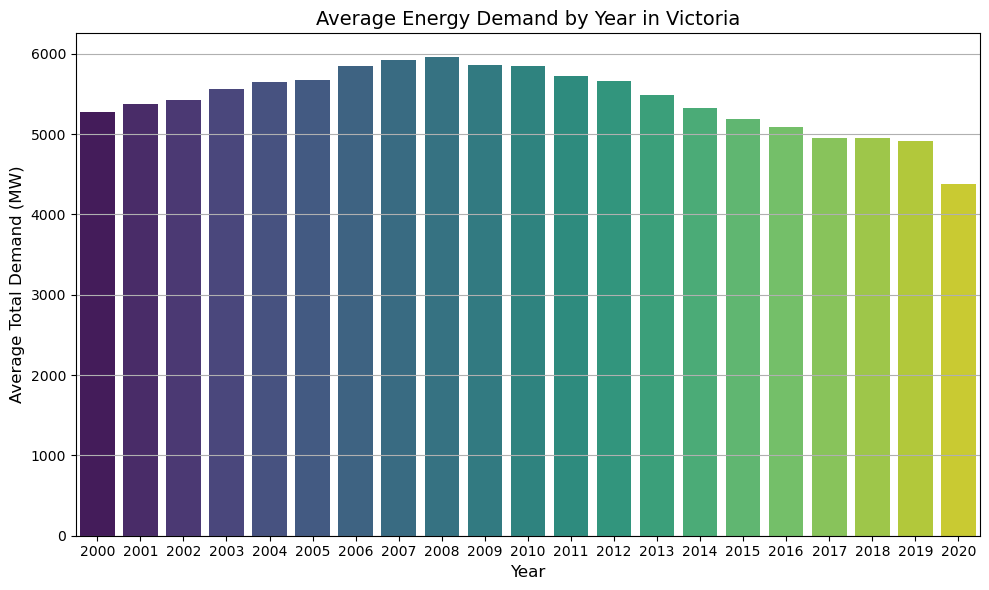

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your code above has already run to load and process the DataFrame `df`
# If not, ensure the previous code is executed to create `df` with 'Year' and 'Demand' columns

# Calculate the average energy demand per year
avg_demand_by_year = df.groupby('Year')['Total Demand'].mean().reset_index()

# Create a bar plot for average energy demand by year
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Total Demand', data=avg_demand_by_year, palette='viridis')
plt.title('Average Energy Demand by Year in Victoria', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Total Demand (MW)', fontsize=12)
plt.grid(True, axis='y')
plt.tight_layout()

# Show the plot
plt.show()